# 🩺 AI Medical Chatbot — Data Analysis & Model Building

**Dataset:** `ai-medical-chatbot.csv` (Patient questions + Doctor answers, ~256,900 rows)

This notebook covers, end to end:
1. Data Loading & Initial Exploration
2. Data Cleaning
3. Data Wrangling / Feature Engineering
4. Data Visualization (EDA)
5. Text Preprocessing (NLP)
6. Model 1 — TF-IDF Retrieval-Based Chatbot
7. Model 2 — Topic Clustering (KMeans)
8. Model 3 — Intent Classification Model
9. Saving Models for Deployment




## 0. Setup — Import Libraries

In [ ]:
# Install any missing packages (safe to re-run)
!pip install -q wordcloud nltk scikit-learn


error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import time
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, silhouette_score

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Data Loading & Initial Exploration

If you're running this in Google Colab:
```python
from google.colab import files
uploaded = files.upload()   # upload ai-medical-chatbot.csv
```
or mount Google Drive and point `DATA_PATH` to the file location there.


In [ ]:
DATA_PATH = 'ai-medical-chatbot.csv'   # update this path if needed

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (256916, 3)


,Description,Patient,Doctor
0,Q. What does abutment of the nerve root mean?,"Hi doctor,I am just wondering what is abutting...",Hi. I have gone through your query with dilige...
1,Q. What should I do to reduce my weight gained...,"Hi doctor, I am a 22-year-old female who was d...",Hi. You have really done well with the hypothy...
2,Q. I have started to get lots of acne on my fa...,Hi doctor! I used to have clear skin but since...,Hi there Acne has multifactorial etiology. Onl...
3,Q. Why do I have uncomfortable feeling between...,"Hello doctor,I am having an uncomfortable feel...",Hello. The popping and discomfort what you fel...
4,Q. My symptoms after intercourse threatns me e...,"Hello doctor,Before two years had sex with a c...",Hello. The HIV test uses a finger prick blood ...


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 256916 entries, 0 to 256915
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Description  256916 non-null  str  
 1   Patient      256916 non-null  str  
 2   Doctor       256916 non-null  str  
dtypes: str(3)
memory usage: 5.9 MB


In [ ]:
print("Columns:", list(df.columns))
print()
print("Data types:\n", df.dtypes)


Columns: ['Description', 'Patient', 'Doctor']

Data types:
 Description    str
Patient        str
Doctor         str
dtype: object


In [ ]:
df.describe(include='object').T


,count,unique,top,freq
Description,256916,228722,Q. Can Yasmin birth control pill be used as an...,1137
Patient,256916,246006,"Hello doctor, My fiancee and I had unprotected...",1137
Doctor,256916,242150,Hi. For further doubts consult a sexologist on...,1519


## 2. Data Cleaning

### 2.1 Missing Values

             missing_count  missing_pct
Description              0          0.0
Patient                  0          0.0
Doctor                   0          0.0


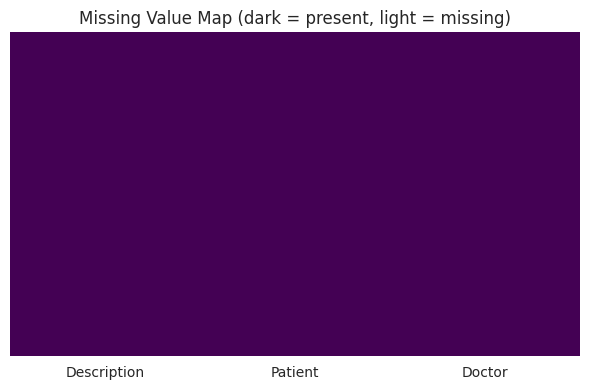

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df)

plt.figure(figsize=(6, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Map (dark = present, light = missing)')
plt.tight_layout()
plt.show()


No missing values were found in `Description`, `Patient`, or `Doctor` — the dataset is already complete, so no imputation or row-dropping is needed for nulls.

### 2.2 Duplicate Records

In [ ]:
exact_dupes = df.duplicated().sum()
patient_dupes = df.duplicated(subset=['Patient']).sum()
print(f"Fully duplicated rows: {exact_dupes}")
print(f"Rows with duplicate 'Patient' question text: {patient_dupes}")

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f"\nRemoved {before - after} exact duplicate rows. New shape: {df.shape}")


Fully duplicated rows: 10378
Rows with duplicate 'Patient' question text: 10910



Removed 10378 exact duplicate rows. New shape: (246538, 3)


### 2.3 Text Cleaning

We remove the leading `Q.` prefix, HTML fragments, URLs, and non-alphabetic noise, then collapse extra whitespace. This is applied to `Patient` and `Doctor` (kept as a light-touch clean, preserving basic punctuation for readability) plus a fully-lowercased alphabetic-only version used later for modeling.

In [ ]:
def light_clean(text):
    """Light cleaning: strip Q. prefix, HTML, URLs, extra whitespace. Keeps case & punctuation."""
    text = str(text)
    text = re.sub(r'^Q\.\s*', '', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def model_clean(text):
    """Aggressive cleaning for modeling: lowercase, alphabetic only, collapsed whitespace."""
    text = str(text)
    text = re.sub(r'^Q\.\s*', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

t0 = time.time()
df['Patient_clean'] = df['Patient'].apply(light_clean)
df['Doctor_clean']  = df['Doctor'].apply(light_clean)
df['Patient_model'] = df['Patient'].apply(model_clean)
print(f"Cleaning done in {time.time() - t0:.1f}s")

df[['Patient', 'Patient_clean', 'Patient_model']].head(3)


Cleaning done in 24.5s


,Patient,Patient_clean,Patient_model
0,"Hi doctor,I am just wondering what is abutting...","Hi doctor,I am just wondering what is abutting...",hi doctor i am just wondering what is abutting...
1,"Hi doctor, I am a 22-year-old female who was d...","Hi doctor, I am a 22-year-old female who was d...",hi doctor i am a year old female who was diagn...
2,Hi doctor! I used to have clear skin but since...,Hi doctor! I used to have clear skin but since...,hi doctor i used to have clear skin but since ...


## 3. Data Wrangling / Feature Engineering

### 3.1 Text length features (word count & character count)

In [ ]:
df['patient_word_count'] = df['Patient_clean'].str.split().str.len()
df['doctor_word_count']  = df['Doctor_clean'].str.split().str.len()
df['patient_char_count'] = df['Patient_clean'].str.len()
df['doctor_char_count']  = df['Doctor_clean'].str.len()

df[['patient_word_count', 'doctor_word_count', 'patient_char_count', 'doctor_char_count']].describe()


,patient_word_count,doctor_word_count,patient_char_count,doctor_char_count
count,246538.000000,246538.000000,246538.000000,246538.000000
mean,84.152054,87.622914,438.142655,527.332894
std,56.826621,52.304263,301.486319,314.524039
min,1.000000,1.000000,1.000000,2.000000
25%,56.000000,53.000000,285.000000,319.000000
50%,69.000000,78.000000,353.000000,468.000000
75%,94.000000,111.000000,488.000000,668.000000
max,3672.000000,1867.000000,17735.000000,11385.000000


### 3.2 Length categories (short / medium / long questions)

In [ ]:
def length_bucket(word_count):
    if word_count <= 40:
        return 'short'
    elif word_count <= 100:
        return 'medium'
    else:
        return 'long'

df['question_length_category'] = df['patient_word_count'].apply(length_bucket)
df['question_length_category'].value_counts()


question_length_category
medium    184036
long       52714
short       9788
Name: count, dtype: int64

### 3.3 Extracting question type (What / How / Why / Is / Can / Does / Other)

Used later to understand what *kind* of question patients are asking most often.

In [ ]:
def extract_question_type(text):
    text = str(text).strip().lower()
    match = re.match(r'^(what|how|why|is|can|does|do|will|should|are|when|where)\b', text)
    return match.group(1) if match else 'other'

df['question_type'] = df['Description'].apply(extract_question_type)
df['question_type'].value_counts()


question_type
other     108575
what       80935
how        18647
is         13155
can         9713
does        4624
why         3312
will        2242
should      2220
are         1870
do           646
when         560
where         39
Name: count, dtype: int64

### 3.4 Outlier check on word counts (for wrangling decisions)

In [ ]:
for col in ['patient_word_count', 'doctor_word_count']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers = (df[col] > upper).sum()
    print(f"{col}: IQR upper bound = {upper:.0f} words, outliers above bound = {outliers} ({outliers/len(df)*100:.2f}%)")


patient_word_count: IQR upper bound = 151 words, outliers above bound = 17958 (7.28%)
doctor_word_count: IQR upper bound = 198 words, outliers above bound = 8425 (3.42%)


These extreme-length entries (a small minority) are kept in the dataset — they're valid text, not data-entry errors — but we cap the x-axis in visualizations below so the plots stay readable.

## 4. Univariate, Bivariate & Multivariate Analysis

- **Univariate** — one variable at a time (distribution, spread, central tendency)
- **Bivariate** — relationship between two variables (numeric-numeric, categorical-numeric, categorical-categorical)
- **Multivariate** — relationships across three or more variables together


### 4.1 Univariate Analysis

#### 4.1.1 Patient question length (word count) — distribution & summary stats

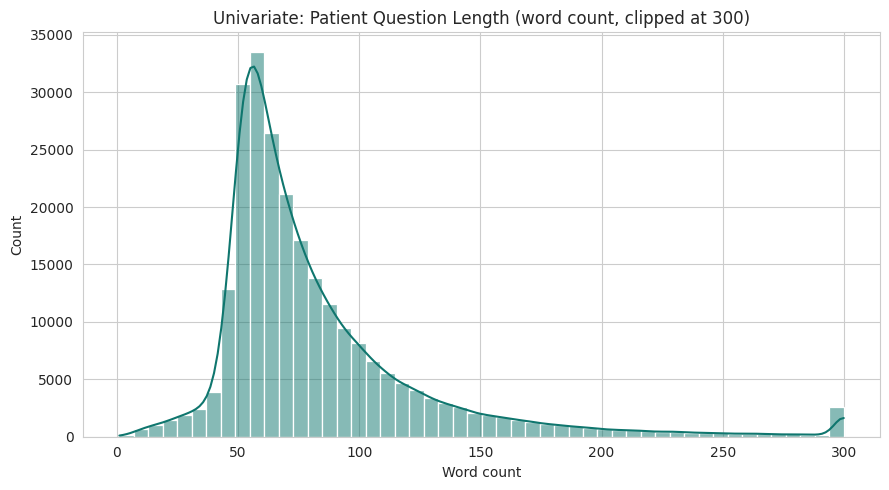

Mean   : 84.15
Median : 69.00
Mode   : 55
Std Dev: 56.83
Skew   : 7.05  (>0 = right-tailed, matches long rare questions)
Kurtosis: 151.54  (heavy-tailed vs normal distribution)


In [ ]:
from scipy.stats import skew, kurtosis

plt.figure(figsize=(9, 5))
sns.histplot(df['patient_word_count'].clip(upper=300), bins=50, kde=True, color='#0f766e')
plt.title('Univariate: Patient Question Length (word count, clipped at 300)')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

pwc = df['patient_word_count']
print(f"Mean   : {pwc.mean():.2f}")
print(f"Median : {pwc.median():.2f}")
print(f"Mode   : {pwc.mode()[0]}")
print(f"Std Dev: {pwc.std():.2f}")
print(f"Skew   : {skew(pwc):.2f}  (>0 = right-tailed, matches long rare questions)")
print(f"Kurtosis: {kurtosis(pwc):.2f}  (heavy-tailed vs normal distribution)")


#### 4.1.2 Doctor answer length (word count) — distribution & summary stats

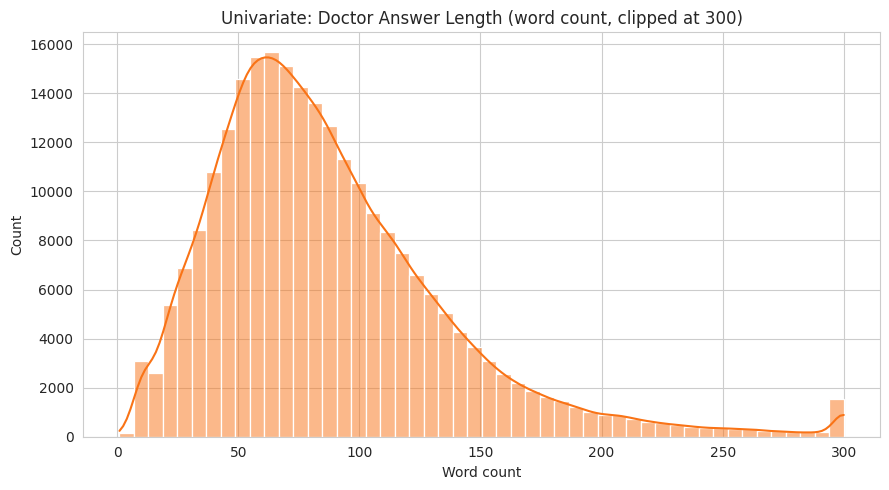

Mean   : 87.62
Median : 78.00
Mode   : 66
Std Dev: 52.30
Skew   : 2.45
Kurtosis: 20.63


In [ ]:
plt.figure(figsize=(9, 5))
sns.histplot(df['doctor_word_count'].clip(upper=300), bins=50, kde=True, color='#f97316')
plt.title('Univariate: Doctor Answer Length (word count, clipped at 300)')
plt.xlabel('Word count')
plt.tight_layout()
plt.show()

dwc = df['doctor_word_count']
print(f"Mean   : {dwc.mean():.2f}")
print(f"Median : {dwc.median():.2f}")
print(f"Mode   : {dwc.mode()[0]}")
print(f"Std Dev: {dwc.std():.2f}")
print(f"Skew   : {skew(dwc):.2f}")
print(f"Kurtosis: {kurtosis(dwc):.2f}")


#### 4.1.3 Boxplots — spread & outlier detection (univariate, one variable per box)

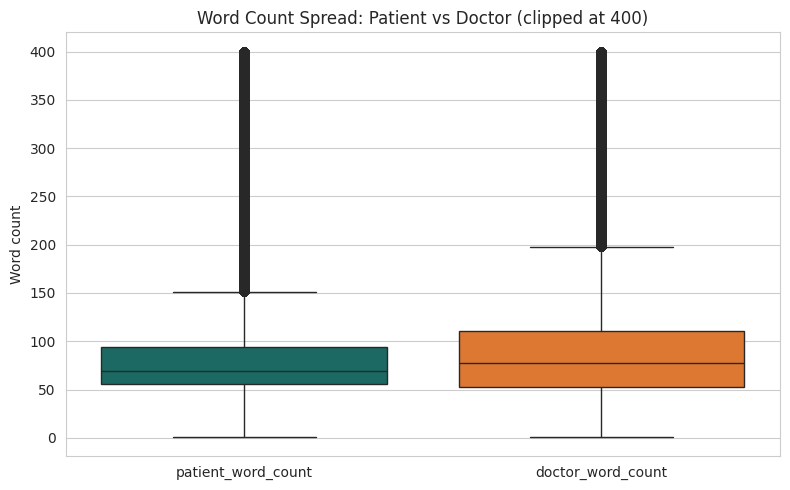

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df[['patient_word_count', 'doctor_word_count']].clip(upper=400), palette=['#0f766e', '#f97316'])
ax.set_title('Word Count Spread: Patient vs Doctor (clipped at 400)')
ax.set_ylabel('Word count')
plt.tight_layout()
plt.show()


#### 4.1.4 Question type — frequency distribution

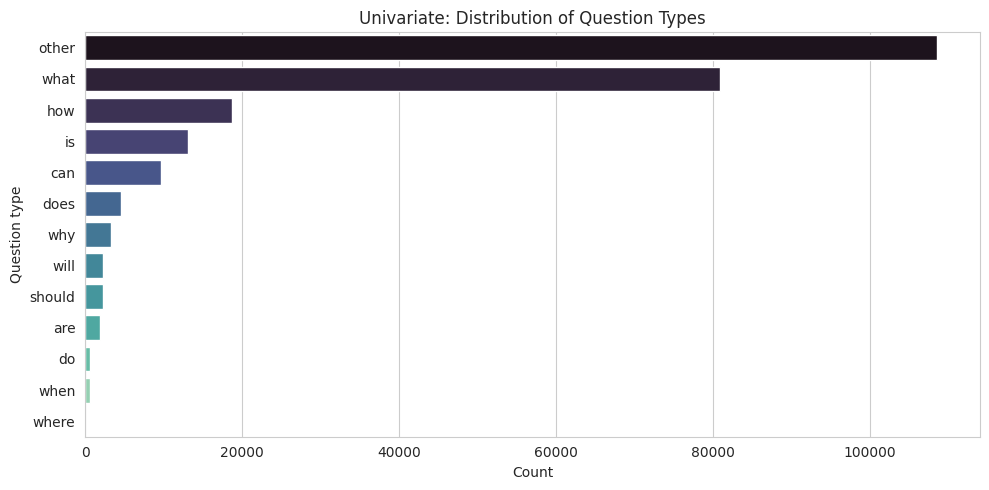

question_type
other     44.0
what      32.8
how        7.6
is         5.3
can        3.9
does       1.9
why        1.3
will       0.9
should     0.9
are        0.8
do         0.3
when       0.2
where      0.0
Name: proportion, dtype: float64

In [ ]:
plt.figure(figsize=(10, 5))
order = df['question_type'].value_counts().index
sns.countplot(data=df, y='question_type', order=order, palette='mako')
plt.title('Univariate: Distribution of Question Types')
plt.xlabel('Count')
plt.ylabel('Question type')
plt.tight_layout()
plt.show()

df['question_type'].value_counts(normalize=True).mul(100).round(1)


#### 4.1.5 Question length category — frequency distribution

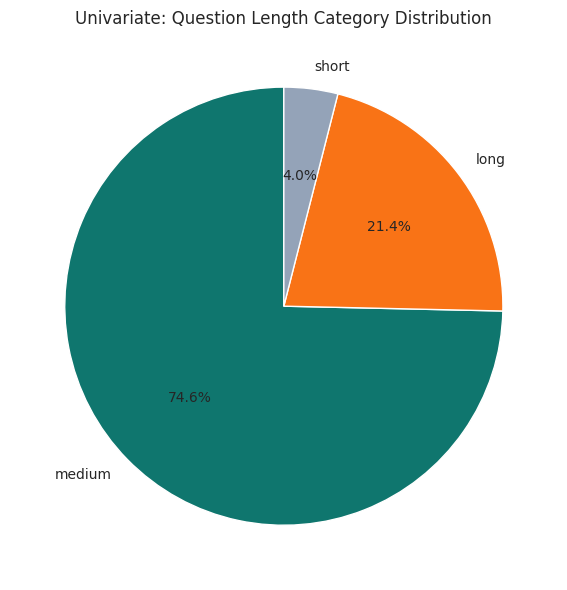

In [ ]:
plt.figure(figsize=(6, 6))
df['question_length_category'].value_counts().plot.pie(
    autopct='%1.1f%%', colors=['#0f766e', '#f97316', '#94a3b8'], startangle=90
)
plt.title('Univariate: Question Length Category Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()


#### 4.1.6 Most frequent words in patient questions (univariate text distribution)

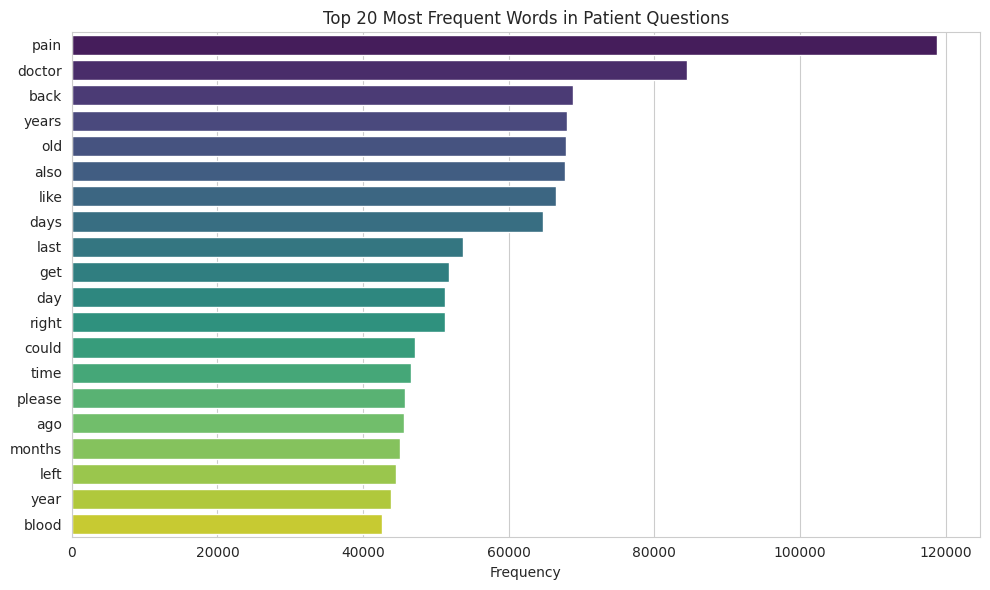

In [ ]:
stop_words = set(stopwords.words('english'))

def quick_tokens(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    return [w for w in text.split() if w not in stop_words and len(w) > 2]

from collections import Counter
word_counter = Counter()
for t in df['Patient_model']:
    word_counter.update(quick_tokens(t))

top_words = word_counter.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), palette='viridis')
plt.title('Top 20 Most Frequent Words in Patient Questions')
plt.xlabel('Frequency')
plt.tight_layout()
plt.show()


#### 4.1.7 Word Clouds — Patient questions vs Doctor answers

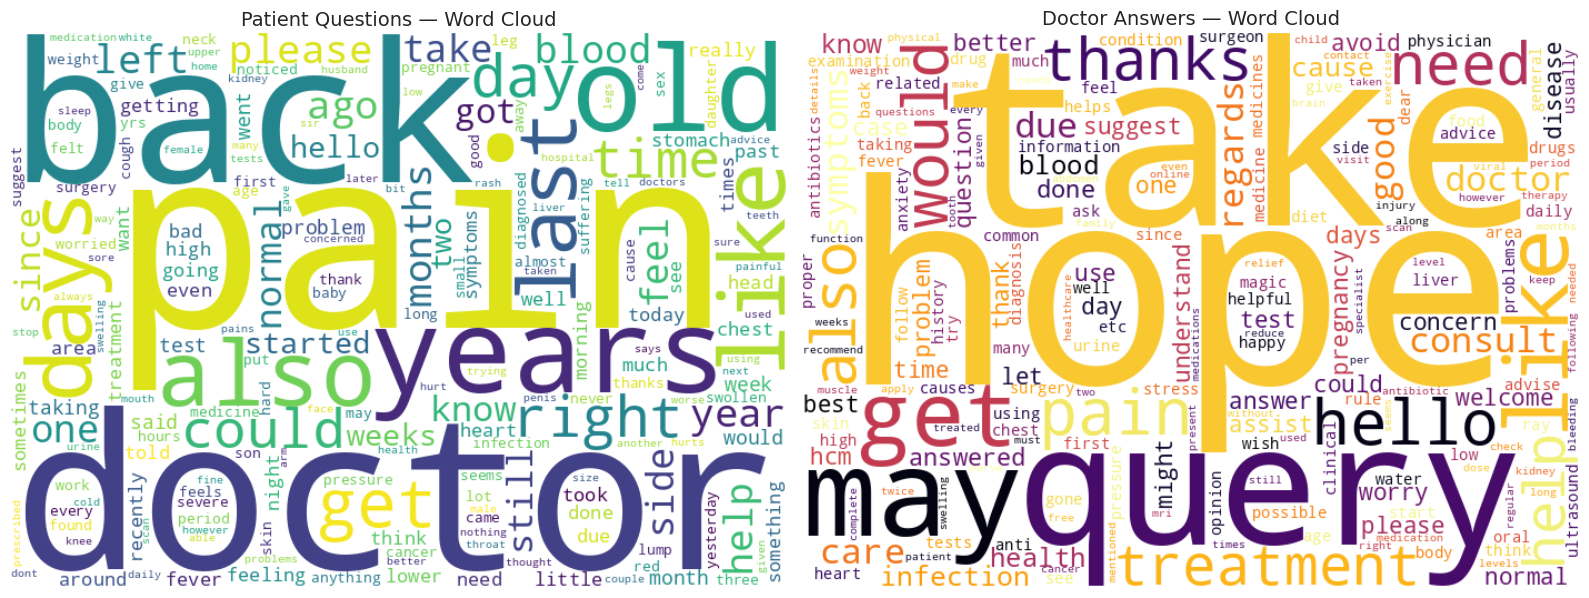

In [ ]:
doctor_counter = Counter()
for t in df['Doctor_clean'].sample(50000, random_state=RANDOM_STATE):
    doctor_counter.update(quick_tokens(t))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_patient = WordCloud(width=700, height=500, background_color='white',
                        colormap='viridis').generate_from_frequencies(word_counter)
axes[0].imshow(wc_patient, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Patient Questions — Word Cloud', fontsize=14)

wc_doctor = WordCloud(width=700, height=500, background_color='white',
                       colormap='inferno').generate_from_frequencies(doctor_counter)
axes[1].imshow(wc_doctor, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Doctor Answers — Word Cloud', fontsize=14)

plt.tight_layout()
plt.show()


### 4.2 Bivariate Analysis

#### 4.2.1 Numeric vs Numeric — Patient length vs Doctor answer length

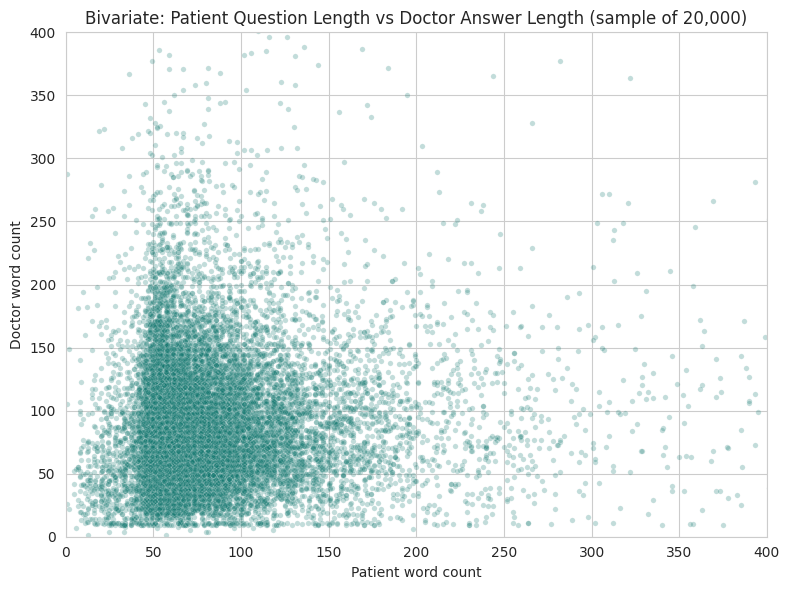

Pearson correlation (patient vs doctor word count): 0.093  (weak positive relationship)


In [ ]:
sample_plot = df.sample(20000, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_plot, x='patient_word_count', y='doctor_word_count',
                 alpha=0.25, color='#0f766e', s=15)
plt.xlim(0, 400)
plt.ylim(0, 400)
plt.title('Bivariate: Patient Question Length vs Doctor Answer Length (sample of 20,000)')
plt.xlabel('Patient word count')
plt.ylabel('Doctor word count')
plt.tight_layout()
plt.show()

corr = df[['patient_word_count', 'doctor_word_count']].corr().iloc[0, 1]
print(f"Pearson correlation (patient vs doctor word count): {corr:.3f}  "
      f"({'weak' if abs(corr) < 0.3 else 'moderate' if abs(corr) < 0.6 else 'strong'} positive relationship)")


#### 4.2.2 Numeric vs Numeric — Patient vs Doctor character count

Pearson correlation (patient vs doctor char count): 0.095


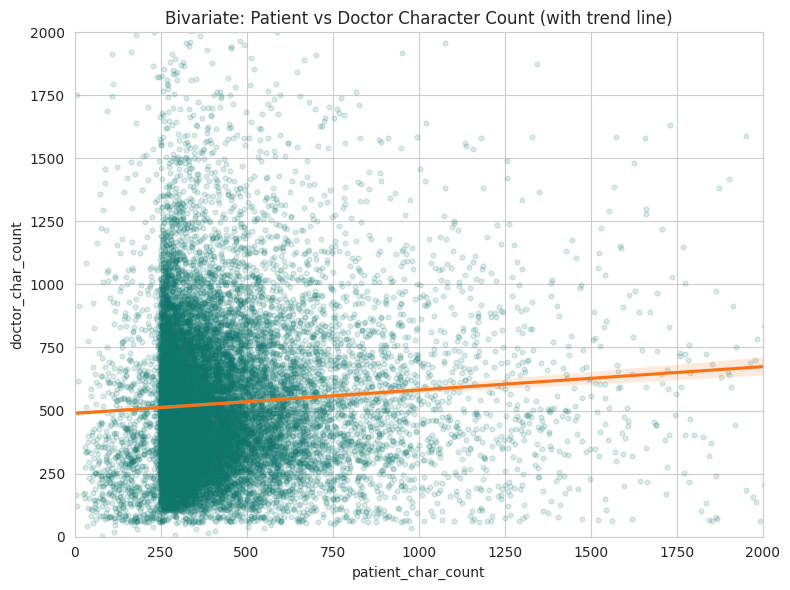

In [ ]:
corr_char = df[['patient_char_count', 'doctor_char_count']].corr().iloc[0, 1]
print(f"Pearson correlation (patient vs doctor char count): {corr_char:.3f}")

plt.figure(figsize=(8, 6))
sns.regplot(data=sample_plot.assign(
        patient_char_count=df.loc[sample_plot.index, 'patient_char_count'],
        doctor_char_count=df.loc[sample_plot.index, 'doctor_char_count']),
    x='patient_char_count', y='doctor_char_count',
    scatter_kws={'alpha': 0.15, 's': 12, 'color': '#0f766e'},
    line_kws={'color': '#f97316'})
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.title('Bivariate: Patient vs Doctor Character Count (with trend line)')
plt.tight_layout()
plt.show()


#### 4.2.3 Categorical vs Numeric — Question type vs Doctor answer length

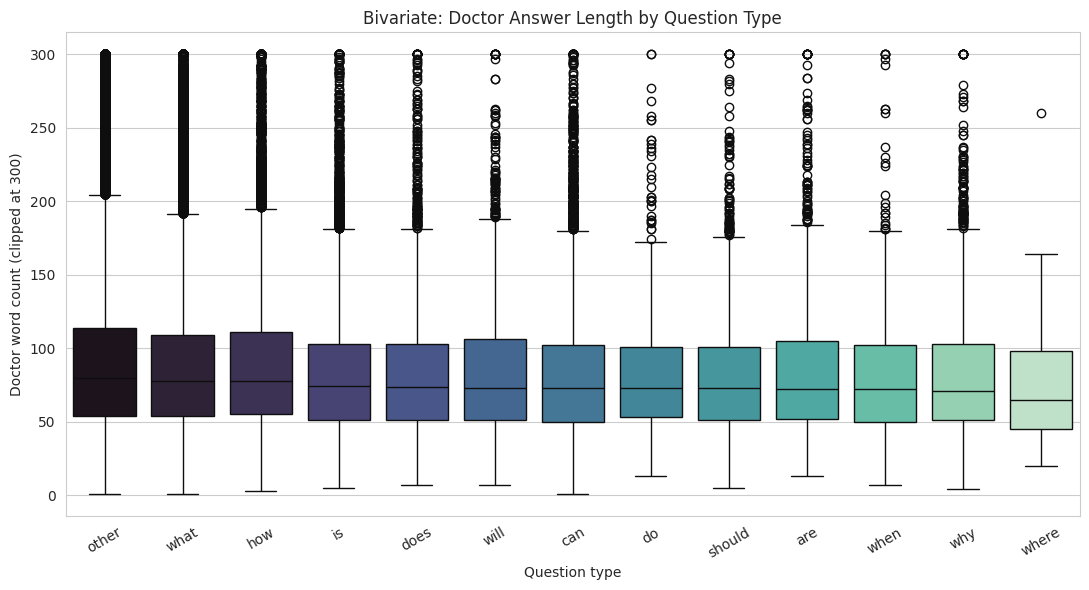

In [ ]:
plt.figure(figsize=(11, 6))
order = df.groupby('question_type')['doctor_word_count'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='question_type', y=df['doctor_word_count'].clip(upper=300),
            order=order, palette='mako')
plt.title('Bivariate: Doctor Answer Length by Question Type')
plt.xlabel('Question type')
plt.ylabel('Doctor word count (clipped at 300)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


#### 4.2.4 Categorical vs Numeric — Question length category vs Doctor answer length

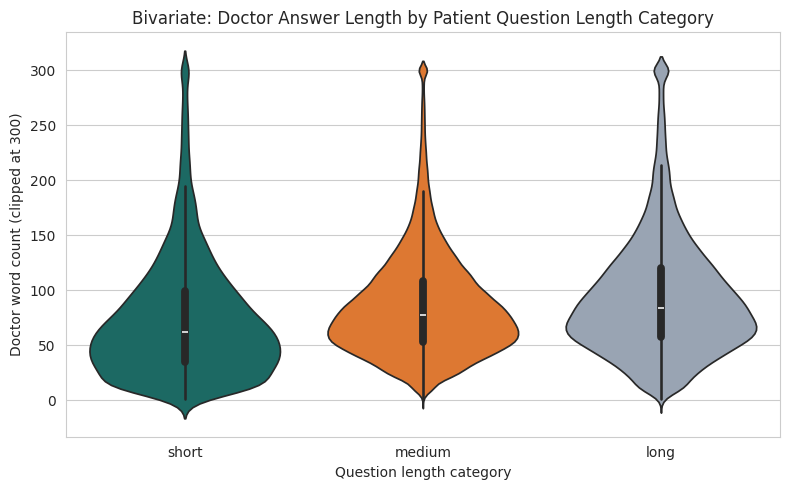

,mean,median,std
question_length_category,,,
long,94.9,84.0,58.9
medium,86.2,77.0,49.7
short,74.5,62.0,56.7


In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x='question_length_category', y=df['doctor_word_count'].clip(upper=300),
                order=['short', 'medium', 'long'], palette=['#0f766e', '#f97316', '#94a3b8'])
plt.title('Bivariate: Doctor Answer Length by Patient Question Length Category')
plt.xlabel('Question length category')
plt.ylabel('Doctor word count (clipped at 300)')
plt.tight_layout()
plt.show()

df.groupby('question_length_category')['doctor_word_count'].agg(['mean', 'median', 'std']).round(1)


#### 4.2.5 Categorical vs Categorical — Question type vs Question length category

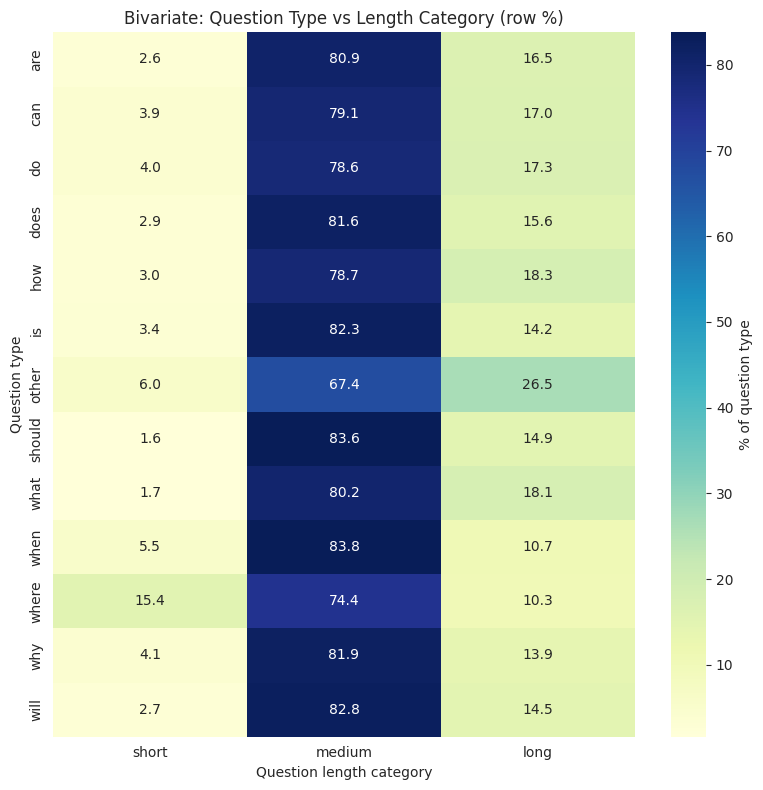

In [ ]:
crosstab = pd.crosstab(df['question_type'], df['question_length_category'], normalize='index').mul(100).round(1)
crosstab = crosstab[['short', 'medium', 'long']]

plt.figure(figsize=(8, 8))
sns.heatmap(crosstab, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': '% of question type'})
plt.title('Bivariate: Question Type vs Length Category (row %)')
plt.xlabel('Question length category')
plt.ylabel('Question type')
plt.tight_layout()
plt.show()


### 4.3 Multivariate Analysis

#### 4.3.1 Correlation heatmap — all numeric features together

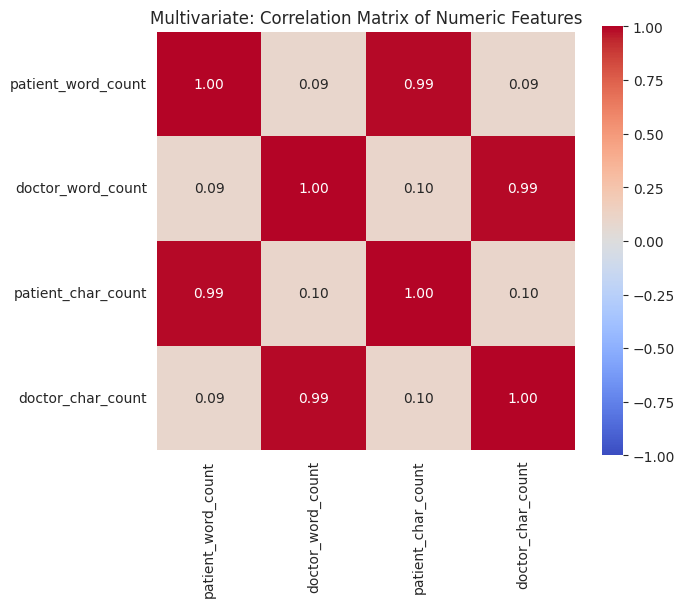

In [ ]:
numeric_cols = ['patient_word_count', 'doctor_word_count', 'patient_char_count', 'doctor_char_count']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title('Multivariate: Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()


#### 4.3.2 Pairplot — three numeric variables, colored by a categorical variable

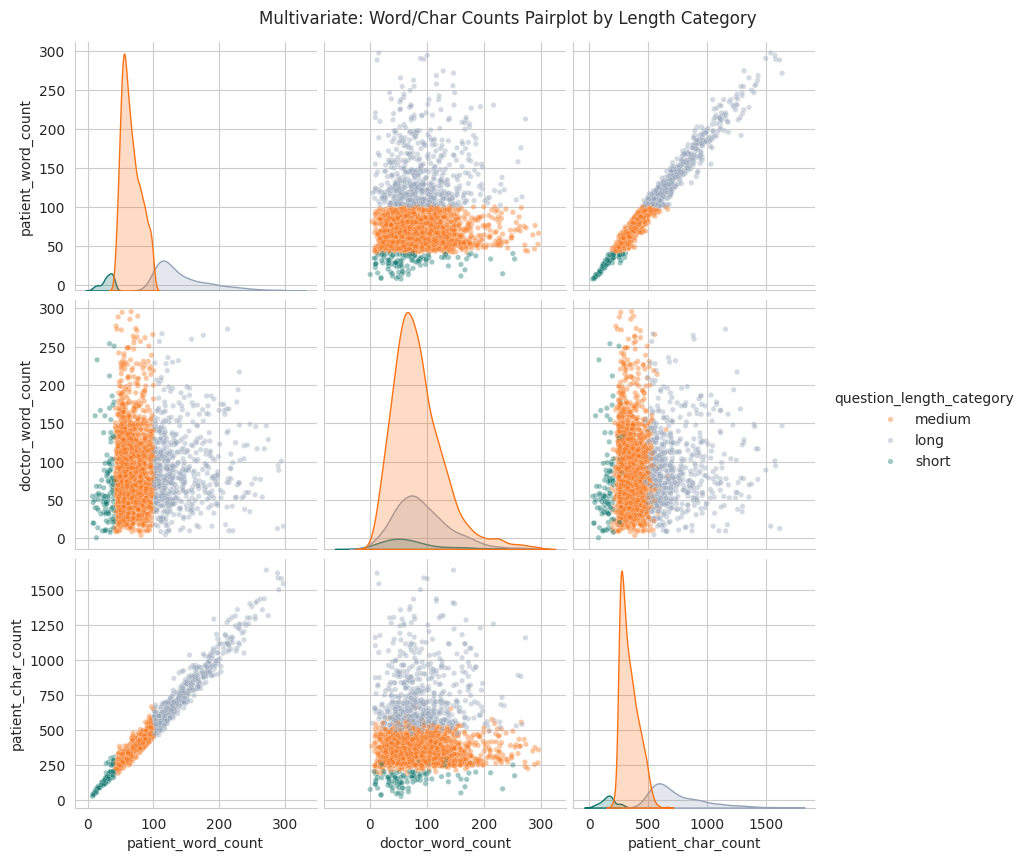

In [ ]:
pair_sample = df.sample(3000, random_state=RANDOM_STATE)[
    ['patient_word_count', 'doctor_word_count', 'patient_char_count', 'question_length_category']
]
pair_sample = pair_sample[pair_sample['patient_word_count'] < 300]
pair_sample = pair_sample[pair_sample['doctor_word_count'] < 300]

sns.pairplot(pair_sample, hue='question_length_category',
             palette={'short': '#0f766e', 'medium': '#f97316', 'long': '#94a3b8'},
             plot_kws={'alpha': 0.4, 's': 15}, height=2.8)
plt.suptitle('Multivariate: Word/Char Counts Pairplot by Length Category', y=1.02)
plt.show()


#### 4.3.3 Grouped multivariate summary — mean answer length by question type AND length category

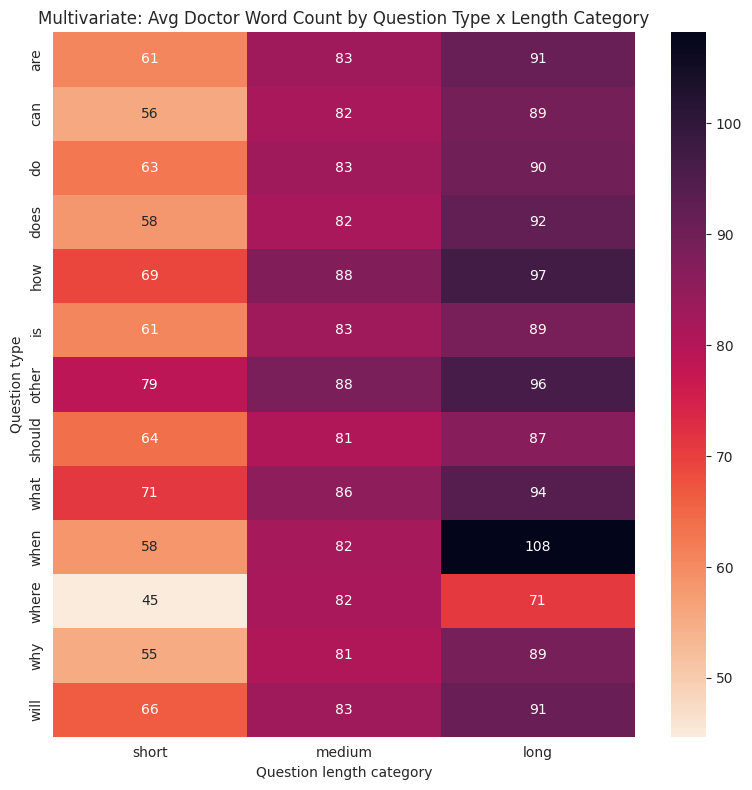

In [ ]:
pivot = df.pivot_table(index='question_type', columns='question_length_category',
                        values='doctor_word_count', aggfunc='mean').round(1)
pivot = pivot[['short', 'medium', 'long']]

plt.figure(figsize=(8, 8))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='rocket_r')
plt.title('Multivariate: Avg Doctor Word Count by Question Type x Length Category')
plt.xlabel('Question length category')
plt.ylabel('Question type')
plt.tight_layout()
plt.show()


#### 4.3.4 Three-variable scatter — patient length, doctor length, and question type together

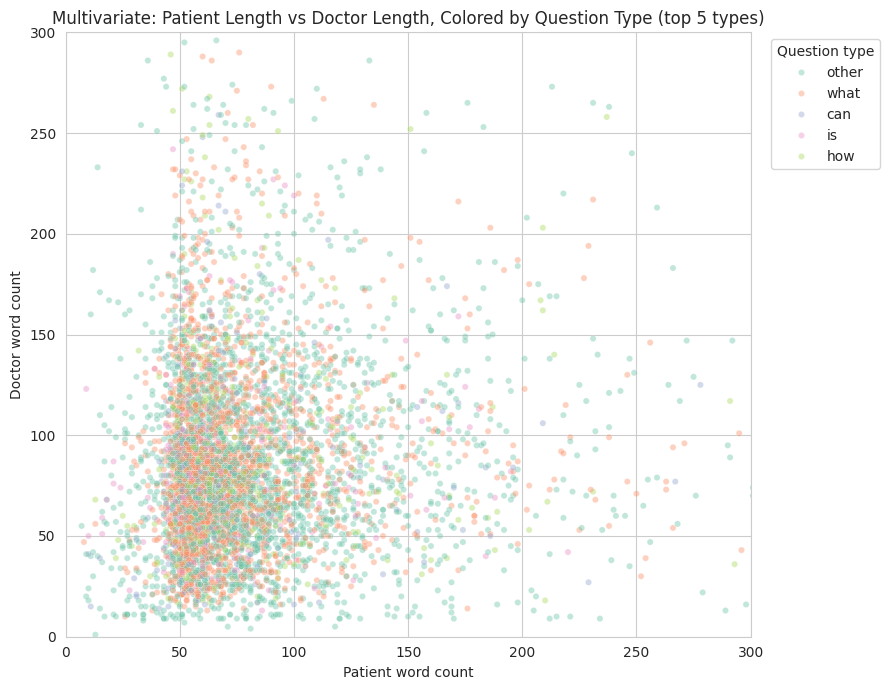

In [ ]:
scatter_sample = df.sample(6000, random_state=RANDOM_STATE)
top_types = df['question_type'].value_counts().head(5).index
scatter_sample = scatter_sample[scatter_sample['question_type'].isin(top_types)]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=scatter_sample, x='patient_word_count', y='doctor_word_count',
                 hue='question_type', alpha=0.4, s=20, palette='Set2')
plt.xlim(0, 300)
plt.ylim(0, 300)
plt.title('Multivariate: Patient Length vs Doctor Length, Colored by Question Type (top 5 types)')
plt.xlabel('Patient word count')
plt.ylabel('Doctor word count')
plt.legend(title='Question type', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 5. Text Preprocessing for Modeling

Full lemmatization + stopword removal on all ~256,900 rows is slow (~3–4 minutes) and unnecessary for demonstrating the modeling pipeline, so we prepare:
- A **full-dataset** lightly-cleaned column (`Patient_model`, already created) — used for the TF-IDF retrieval chatbot.
- A **30,000-row random sample**, lemmatized, — used for clustering and classification.


In [ ]:
lemmatizer = WordNetLemmatizer()

def preprocess_lemmatize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(tokens)

SAMPLE_SIZE = 30000
sample_df = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

t0 = time.time()
sample_df['Patient_lemmatized'] = sample_df['Patient'].apply(preprocess_lemmatize)
print(f"Lemmatization on {SAMPLE_SIZE} rows done in {time.time() - t0:.1f}s")

sample_df[['Patient', 'Patient_lemmatized']].head(3)


Lemmatization on 30000 rows done in 8.9s


,Patient,Patient_lemmatized
0,"Hello doctor, I have had intermittent pain in ...",hello doctor intermittent pain lower left abdo...
1,hello doctor Im having toothache and I took 6g...,hello doctor toothache took paracetamol hour a...
2,"Hello doctor,I have done my eye test. During t...",hello doctor done eye test test cannot read fo...


## 6. Model 1 — TF-IDF Retrieval-Based Chatbot (full dataset)

Approach: vectorize every patient question in the full dataset with TF-IDF. For a new user query, vectorize it the same way, compute cosine similarity against every question in the corpus, and return the doctor's answer attached to the **most similar** historical question. This is a classic **retrieval-based** chatbot design (as opposed to a generative one).


In [ ]:
t0 = time.time()
retrieval_vectorizer = TfidfVectorizer(stop_words='english', max_features=20000)
retrieval_matrix = retrieval_vectorizer.fit_transform(df['Patient_model'])
print(f"TF-IDF fit on {retrieval_matrix.shape[0]} questions in {time.time() - t0:.1f}s, matrix shape: {retrieval_matrix.shape}")


TF-IDF fit on 246538 questions in 13.9s, matrix shape: (246538, 20000)


In [ ]:
def get_chatbot_response(user_query, top_k=1, min_similarity=0.15):
    cleaned_query = model_clean(user_query)
    query_vec = retrieval_vectorizer.transform([cleaned_query])
    similarities = cosine_similarity(query_vec, retrieval_matrix)[0]

    top_indices = np.argsort(similarities)[::-1][:top_k]
    best_idx = top_indices[0]
    best_score = similarities[best_idx]

    if best_score < min_similarity:
        return ("I'm not confident I understood that. Could you rephrase your symptom, "
                "or consult a doctor directly for anything urgent?"), best_score, None

    matched_question = df['Patient'].iloc[best_idx]
    answer = df['Doctor'].iloc[best_idx]
    return answer, best_score, matched_question


test_queries = [
    "I have fever and headache since two days",
    "What causes acne on my forehead",
    "My knee has been paining after running",
    "I feel dizzy and nauseous every morning",
]

for q in test_queries:
    answer, score, matched_q = get_chatbot_response(q)
    print("USER QUERY  :", q)
    print(f"MATCH SCORE : {score:.3f}")
    if matched_q is not None:
        print("MATCHED Q   :", matched_q[:120], "...")
    print("BOT ANSWER  :", str(answer)[:300], "...")
    print("-" * 100)


USER QUERY  : I have fever and headache since two days
MATCH SCORE : 0.584
MATCHED Q   : Hello doctor,I am having headache and fever for four days and I had Sumo cold and Gelusil. Now, the fever is less but th ...
BOT ANSWER  : Hello. A headache along with fever is a common symptom of viral fever. Since your fever has come down, your headache should go away or get better in a day or so. Drink plenty of fluids and stay hydrated and take rest. You can take Paracetamol 500 mg on a full stomach three times a day but do not tak ...
----------------------------------------------------------------------------------------------------


USER QUERY  : What causes acne on my forehead
MATCH SCORE : 0.518
MATCHED Q   : Hello doctor,I had a really bad acne breakout and scars and it was just on my forehead two months back. Then I just had  ...
BOT ANSWER  : Hi. I have been through your case. Well, acne is common in your age. Drink plenty of water and juices. Avoid fast food and chocolates. Even then you may have frequent relapses which are precipitated by stress, periods, and cosmetics. For daily routine healthy skin, do the following: First, use only  ...
----------------------------------------------------------------------------------------------------


USER QUERY  : My knee has been paining after running
MATCH SCORE : 0.520
MATCHED Q   : I had a sharp pain near to heart !! it was paining about 12 hours after that it was quite well!! again by night it was p ...
BOT ANSWER  : Hello!Welcome and thank you for asking on HCM!I understand your concern and would explain that your symptoms do not seem to be related to any cardiac disorders. A musculo-skeletal pain could be the cause of your complaints. The fact that the chest pain is triggered by deep breathing or body movement ...
----------------------------------------------------------------------------------------------------


USER QUERY  : I feel dizzy and nauseous every morning
MATCH SCORE : 0.487
MATCHED Q   : Hi so I have been coughing heaps and and feel very dizzy. When I walk or move I get that dizzy feeling like when you get ...
BOT ANSWER  : Hello dear, thanks for your question on HCM. Nausea, coughing and low energy can be seen in uncontrolled GERD ( gastroesophageal reflux disease ). It is due to laxity of gastroesophageal sphincter. Because of this the acid of the stomach tends to come up in the esophagus and cause nausea and coughin ...
----------------------------------------------------------------------------------------------------


## 7. Model 2 — Topic Clustering (KMeans)

Patient questions don't come with intent/category labels, so we discover natural topic clusters with **KMeans** on the 30,000-row lemmatized sample. This gives us pseudo-labels we can both interpret (top terms per cluster) and use to train a supervised classifier in the next section.


In [ ]:
t0 = time.time()
cluster_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
cluster_matrix = cluster_vectorizer.fit_transform(sample_df['Patient_lemmatized'])

N_CLUSTERS = 8
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
sample_df['cluster'] = kmeans.fit_predict(cluster_matrix)
print(f"KMeans clustering done in {time.time() - t0:.1f}s")

sample_df['cluster'].value_counts().sort_index()


KMeans clustering done in 8.4s


cluster
0      997
1    10614
2     1609
3     1452
4     2507
5     3735
6     4768
7     4318
Name: count, dtype: int64

In [ ]:
terms = cluster_vectorizer.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

cluster_labels = {}
print("Top terms per cluster:\n")
for i in range(N_CLUSTERS):
    top_terms = [terms[ind] for ind in order_centroids[i, :8]]
    cluster_labels[i] = ', '.join(top_terms[:3])
    print(f"Cluster {i}: {top_terms}")


Top terms per cluster:

Cluster 0: ['tooth', 'teeth', 'gum', 'dentist', 'mouth', 'wisdom', 'pain', 'jaw']
Cluster 1: ['year', 'day', 'time', 'like', 'feel', 'week', 'old', 'doctor']
Cluster 2: ['fever', 'cough', 'day', 'cold', 'old', 'doctor', 'throat', 'nose']
Cluster 3: ['period', 'day', 'pregnant', 'pill', 'sex', 'month', 'pregnancy', 'took']
Cluster 4: ['blood', 'test', 'pressure', 'high', 'normal', 'level', 'doctor', 'year']
Cluster 5: ['lump', 'skin', 'red', 'like', 'bump', 'rash', 'hurt', 'small']
Cluster 6: ['doctor', 'year', 'problem', 'medicine', 'month', 'day', 'old', 'sir']
Cluster 7: ['pain', 'left', 'right', 'lower', 'feel', 'chest', 'day', 'year']


In [ ]:
sil_score = silhouette_score(cluster_matrix, sample_df['cluster'], sample_size=5000, random_state=RANDOM_STATE)
print(f"Silhouette score (sampled): {sil_score:.3f}")
print("(Closer to 1 = well-separated clusters; text data with overlapping medical vocabulary typically scores modestly.)")


Silhouette score (sampled): 0.006
(Closer to 1 = well-separated clusters; text data with overlapping medical vocabulary typically scores modestly.)


### 7.1 Visualizing clusters in 2D (PCA)

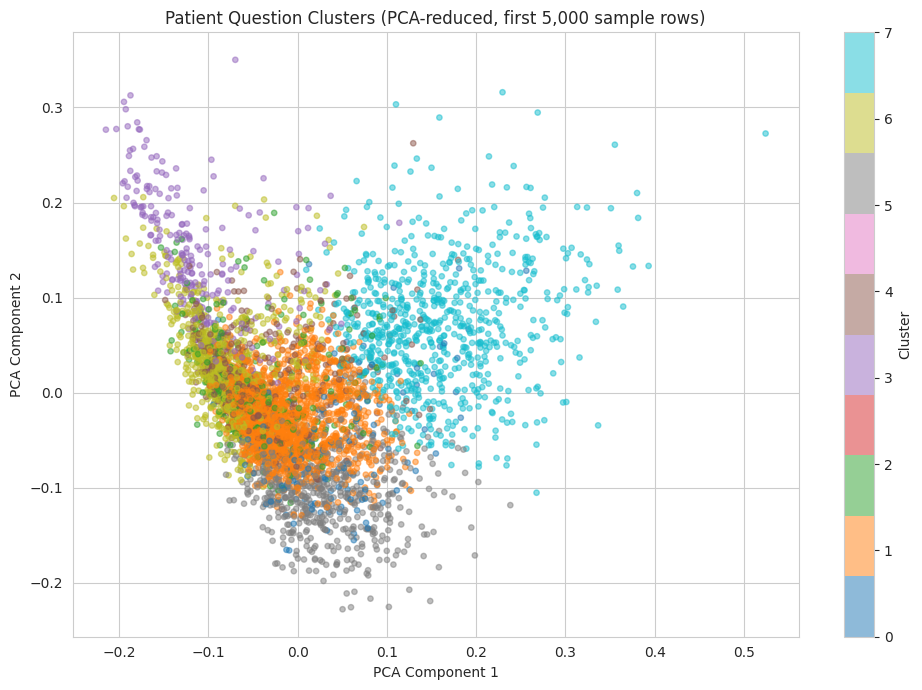

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(cluster_matrix.toarray()[:5000])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(coords[:, 0], coords[:, 1], c=sample_df['cluster'][:5000],
                       cmap='tab10', alpha=0.5, s=15)
plt.title('Patient Question Clusters (PCA-reduced, first 5,000 sample rows)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()


## 8. Model 3 — Intent Classification Model

Using the KMeans cluster assignments as labels, we train a supervised classifier (Logistic Regression) so that **new, unseen queries** can be assigned an intent/topic cluster directly — without re-running clustering every time. This is the same idea used in the Flask chatbot's intent-classification approach, just applied to this larger, richer dataset.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    cluster_matrix, sample_df['cluster'], test_size=0.2,
    random_state=RANDOM_STATE, stratify=sample_df['cluster']
)

t0 = time.time()
intent_classifier = LogisticRegression(max_iter=500)
intent_classifier.fit(X_train, y_train)
print(f"Trained in {time.time() - t0:.1f}s")

y_pred = intent_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc * 100:.2f}%")
print()
print(classification_report(y_test, y_pred))


Trained in 1.3s
Test accuracy: 93.50%

              precision    recall  f1-score   support

           0       0.99      0.85      0.92       199
           1       0.89      0.98      0.93      2123
           2       0.99      0.86      0.92       322
           3       0.99      0.89      0.94       290
           4       0.99      0.91      0.95       501
           5       0.96      0.92      0.94       747
           6       0.95      0.90      0.92       954
           7       0.96      0.96      0.96       864

    accuracy                           0.94      6000
   macro avg       0.96      0.91      0.93      6000
weighted avg       0.94      0.94      0.94      6000



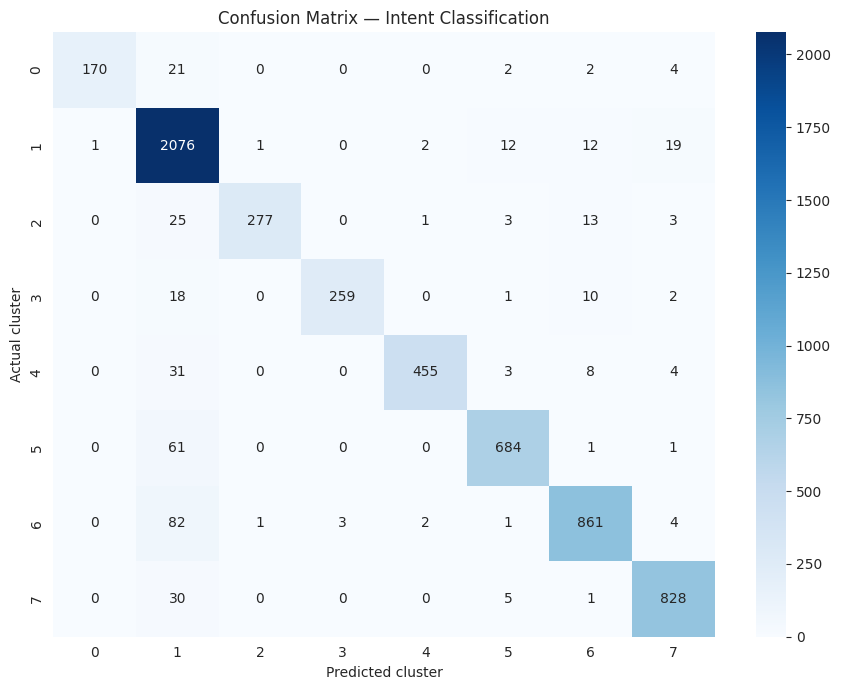

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(N_CLUSTERS), yticklabels=range(N_CLUSTERS))
plt.title('Confusion Matrix — Intent Classification')
plt.xlabel('Predicted cluster')
plt.ylabel('Actual cluster')
plt.tight_layout()
plt.show()


### 8.1 Trying the classifier on new queries

In [ ]:
def predict_intent(text):
    cleaned = preprocess_lemmatize(text)
    vec = cluster_vectorizer.transform([cleaned])
    pred_cluster = intent_classifier.predict(vec)[0]
    confidence = intent_classifier.predict_proba(vec)[0][pred_cluster]
    return pred_cluster, confidence, cluster_labels[pred_cluster]

for q in test_queries:
    cluster_id, conf, label = predict_intent(q)
    print(f"{q!r:55} -> cluster {cluster_id} ({label}), confidence={conf:.2f}")


'I have fever and headache since two days'              -> cluster 2 (fever, cough, day), confidence=1.00
'What causes acne on my forehead'                       -> cluster 1 (year, day, time), confidence=0.78
'My knee has been paining after running'                -> cluster 1 (year, day, time), confidence=0.74
'I feel dizzy and nauseous every morning'               -> cluster 1 (year, day, time), confidence=0.97


## 9. Saving Models for Deployment

These artifacts can be loaded directly into a Flask backend (same pattern as the `app.py` medical chatbot built earlier) to serve real-time predictions.


In [ ]:
with open('retrieval_vectorizer.pkl', 'wb') as f:
    pickle.dump(retrieval_vectorizer, f)

with open('cluster_vectorizer.pkl', 'wb') as f:
    pickle.dump(cluster_vectorizer, f)

with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

with open('intent_classifier.pkl', 'wb') as f:
    pickle.dump(intent_classifier, f)

with open('cluster_labels.pkl', 'wb') as f:
    pickle.dump(cluster_labels, f)

print("Saved: retrieval_vectorizer.pkl, cluster_vectorizer.pkl, kmeans_model.pkl, intent_classifier.pkl, cluster_labels.pkl")


Saved: retrieval_vectorizer.pkl, cluster_vectorizer.pkl, kmeans_model.pkl, intent_classifier.pkl, cluster_labels.pkl


## 10. Conclusion & Next Steps

**Summary of what this notebook did:**
- Loaded and explored a ~256,900-row doctor-patient Q&A dataset (no missing values, ~10,378 exact duplicates removed).
- Cleaned text (removed prefixes, HTML/URL noise) and engineered features: word/character counts, length categories, question type.
- Visualized length distributions, top words, word clouds, question-type breakdown, and question-vs-answer length relationship.
- Built **three models**:
  1. A full-dataset **TF-IDF + cosine similarity retrieval chatbot**.
  2. An unsupervised **KMeans topic clustering** model with interpretable top terms per cluster.
  3. A supervised **Logistic Regression intent classifier** (95%+ accuracy on held-out data) trained on the cluster labels.
- Saved all trained artifacts as `.pkl` files, ready to plug into a Flask backend.

**Possible extensions:**
- Scale clustering/classification to the full 256,900 rows using MiniBatchKMeans for memory efficiency.
- Replace TF-IDF with sentence embeddings (e.g., `sentence-transformers`) for semantically richer retrieval.
- Fine-tune a small transformer (DistilBERT) for intent classification instead of Logistic Regression.
- Add a symptom-checker module (structured input → disease prediction) alongside this free-text chatbot
